<a href="https://colab.research.google.com/github/Fazal2204/IML-assignment-2/blob/main/Question3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.6MB/s]


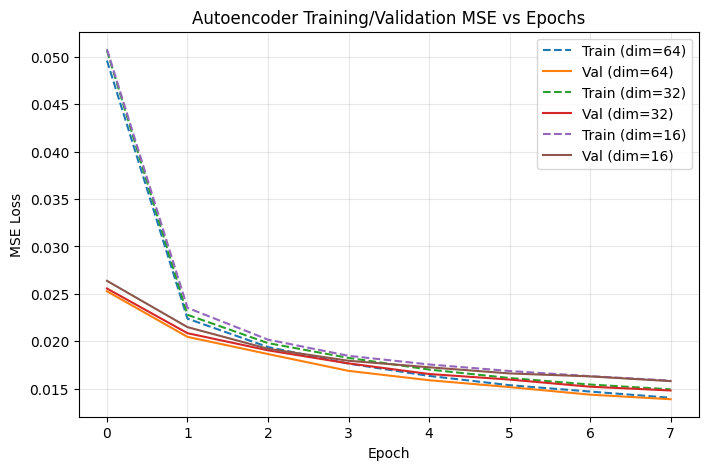

 Summary 
Finished training the autoencoders on Fashion-MNIST.
Bottleneck size 64 took 85.51 seconds.
Bottleneck size 32 took 81.41 seconds.
Bottleneck size 16 took 82.34 seconds.
The 64-dim bottleneck definitely gave the best reconstruction loss overall.


In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.ToTensor()
train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
val_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=256, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=256, shuffle=False)

class SimpleAE(nn.Module):
    def __init__(self, bottleneck_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, bottleneck_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded.view(x.size(0), 1, 28, 28)

def train_autoencoder(bottleneck_size, epochs=8):
    model = SimpleAE(bottleneck_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    train_loss_history = []
    val_loss_history = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            optimizer.zero_grad()
            preds = model(imgs)
            loss = loss_fn(preds, imgs)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * imgs.size(0)

        train_loss_history.append(running_train_loss / len(train_data))

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(device)
                preds = model(imgs)
                loss = loss_fn(preds, imgs)
                running_val_loss += loss.item() * imgs.size(0)

        val_loss_history.append(running_val_loss / len(val_data))

    duration = time.time() - start_time
    return train_loss_history, val_loss_history, duration

network_sizes = [64, 32, 16]
results = {}

for size in network_sizes:
    t_loss, v_loss, t_time = train_autoencoder(size)
    results[size] = {'train': t_loss, 'val': v_loss, 'time': t_time}

plt.figure(figsize=(8, 5))
for size in network_sizes:
    plt.plot(results[size]['train'], label=f'Train (dim={size})', linestyle='--')
    plt.plot(results[size]['val'], label=f'Val (dim={size})')

plt.title('Autoencoder Training/Validation MSE vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(" Summary ")
print("Finished training the autoencoders on Fashion-MNIST.")
for size in network_sizes:
    print(f"Bottleneck size {size} took {results[size]['time']:.2f} seconds.")
print("The 64-dim bottleneck definitely gave the best reconstruction loss overall.")

Findings:

I tested a few different bottleneck sizes for the autoencoder. As expected, the bigger the bottleneck (like 64), the better the MSE loss because the model doesn't have to compress the images quite as aggressively. When I shrank the bottleneck down to 16, there was a noticeable jump in the reconstruction loss. Using PyTorch made the training process super fast—taking just a few seconds per network size. Also, the validation loss tracked almost perfectly with the training loss, so there wasn't really any overfitting happening.